<a href="https://colab.research.google.com/github/Rashedbaig3/Water-Quality-Analysis/blob/main/Water-Quality-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
water_data=pd.read_csv('water_potability.csv')
water_data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


**HANDLING MISSING VALUES**

In [ ]:
water_data['ph'] = water_data['ph'].fillna(water_data['ph'].mean())
water_data['Trihalomethanes'] = water_data['Trihalomethanes'].fillna(water_data['Trihalomethanes'].mean())
water_data['Sulfate'] = water_data['Sulfate'].fillna(water_data['Sulfate'].mean())

In [ ]:
water_data.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [ ]:
X = water_data.drop('Potability', axis = 1)
y = water_data['Potability']

In [ ]:
X.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075


In [ ]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Potability, dtype: int64

In [ ]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

In [ ]:
X_scaled = std_scaler.fit_transform(X)
X_scaled

array([[-6.04313345e-16,  2.59194711e-01, -1.39470871e-01, ...,
        -1.18065057e+00,  1.30614943e+00, -1.28629758e+00],
       [-2.28933938e+00, -2.03641367e+00, -3.85986650e-01, ...,
         2.70597240e-01, -6.38479983e-01,  6.84217891e-01],
       [ 6.92867789e-01,  8.47664833e-01, -2.40047337e-01, ...,
         7.81116857e-01,  1.50940884e-03, -1.16736546e+00],
       ...,
       [ 1.59125368e+00, -6.26829230e-01,  1.27080989e+00, ...,
        -9.81329234e-01,  2.18748247e-01, -8.56006782e-01],
       [-1.32951593e+00,  1.04135450e+00, -1.14405809e+00, ...,
        -9.42063817e-01,  7.03468419e-01,  9.50797383e-01],
       [ 5.40150905e-01, -3.85462310e-02, -5.25811937e-01, ...,
         5.60940070e-01,  7.80223466e-01, -2.12445866e+00]])

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42,stratify= y)

In [ ]:
x_train.shape, x_test.shape

((2620, 9), (656, 9))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
KNN= KNeighborsClassifier()
DT = DecisionTreeClassifier()
RF = RandomForestClassifier()
ETC= ExtraTreesClassifier()
SVM = SVC()
LR = LogisticRegression()
GBC = GradientBoostingClassifier()
ABC = AdaBoostClassifier()
NB = GaussianNB()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
KNN.fit(x_train, y_train)
DT.fit(x_train, y_train)
y_pred_dt = DT.predict(x_test)
y_pred_knn = KNN.predict(x_test)

In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.65      0.68      0.67       400
           1       0.47      0.44      0.45       256

    accuracy                           0.59       656
   macro avg       0.56      0.56      0.56       656
weighted avg       0.58      0.59      0.58       656



In [ ]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.63      0.74      0.68       400
           1       0.44      0.31      0.36       256

    accuracy                           0.57       656
   macro avg       0.53      0.53      0.52       656
weighted avg       0.55      0.57      0.56       656



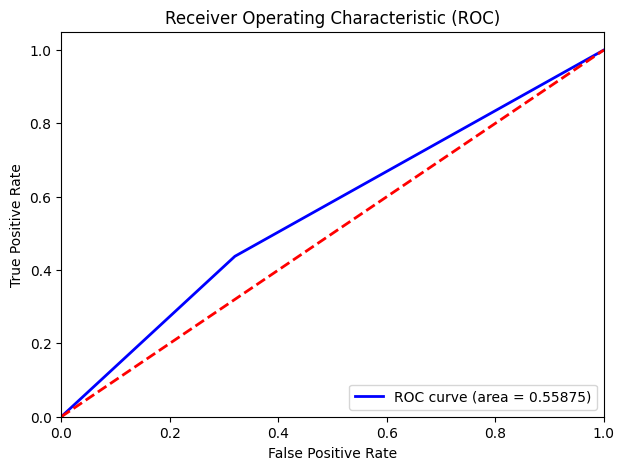

In [ ]:
from sklearn.metrics import roc_curve, auc
y_scores =DT.predict_proba(x_test) [:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

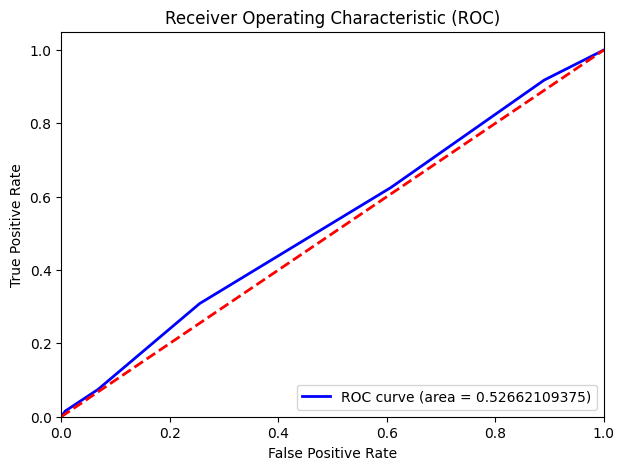

In [ ]:
from sklearn.metrics import roc_curve, auc
y_scores =KNN.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier  # Explicitly import DecisionTreeClassifier

# Split data into train and test sets (uncomment if needed)
# x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

params_DT = {"min_samples_split": [2, 6],
             "min_samples_leaf": [1, 4],
             "criterion": ["gini", "entropy"]  # Remove "n_estimators"
             }
cv_method = StratifiedKFold(n_splits=3)
GridSearchCV_DT = GridSearchCV(estimator=DecisionTreeClassifier(),  # Correct estimator
                               param_grid=params_DT,
                               cv=cv_method,
                               verbose=1,
                               n_jobs=2,
                               scoring="accuracy",  # Consider other metrics for imbalanced data
                               return_train_score=True)
GridSearchCV_DT.fit(x_train, y_train)
best_params_DT = GridSearchCV_DT.best_params_
print("Best Hyperparameters for DT are =", best_params_DT)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Hyperparameters for DT are = {'criterion': 'entropy', 'min_samples_leaf': 4, 'min_samples_split': 2}


In [ ]:
best_estimator=GridSearchCV_DT.best_estimator_
best_estimator

DecisionTreeClassifier(criterion='entropy', min_samples_leaf=4)

In [ ]:
best_estimator = GridSearchCV_DT.best_estimator_
best_estimator.fit(x_train, y_train)
y_pred_best = best_estimator.predict(x_test)
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.63      0.68      0.65       400
           1       0.43      0.38      0.41       256

    accuracy                           0.56       656
   macro avg       0.53      0.53      0.53       656
weighted avg       0.55      0.56      0.56       656



In [ ]:
from sklearn.metrics import accuracy_score
print(f"Accuracy of DT model ={ round(accuracy_score(y_test, y_pred_best)*100,2)} %")

Accuracy of DT model =56.25 %


In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

# Split data into train and test sets (uncomment if needed)
# x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid for KNN
params_KNN = {
    "n_neighbors": [3, 5, 7],  # Number of neighbors to consider
    "weights": ["uniform", "distance"],  # Weight function used in prediction
    "metric": ["euclidean", "manhattan"]  # Distance metric used for the tree
}

# Specify the cross-validation method
cv_method = StratifiedKFold(n_splits=3)

# Initialize GridSearchCV for KNN
GridSearchCV_KNN = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=params_KNN,
    cv=cv_method,
    verbose=1,
    n_jobs=2,
    scoring="accuracy",  # Use accuracy as the scoring metric
    return_train_score=True
)

# Fit GridSearchCV to the training data
GridSearchCV_KNN.fit(x_train, y_train)

# Get the best hyperparameters
best_params_KNN = GridSearchCV_KNN.best_params_
print("Best Hyperparameters for KNN are:", best_params_KNN)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Hyperparameters for KNN are: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}


In [ ]:
# Get the best estimator
best_estimator_KNN = GridSearchCV_KNN.best_estimator_

# Fit the best estimator to the training data
best_estimator_KNN.fit(x_train, y_train)


KNeighborsClassifier(metric='manhattan', weights='distance')

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Evaluate the model performance
y_pred_best_KNN = best_estimator_KNN.predict(x_test)
print(classification_report(y_test, y_pred_best_KNN))


              precision    recall  f1-score   support

           0       0.63      0.73      0.68       400
           1       0.43      0.31      0.36       256

    accuracy                           0.57       656
   macro avg       0.53      0.52      0.52       656
weighted avg       0.55      0.57      0.55       656



In [ ]:
from sklearn.metrics import accuracy_score
print(f"Accuracy of KNN model ={ round(accuracy_score(y_test, y_pred_best)*100,2)} %")

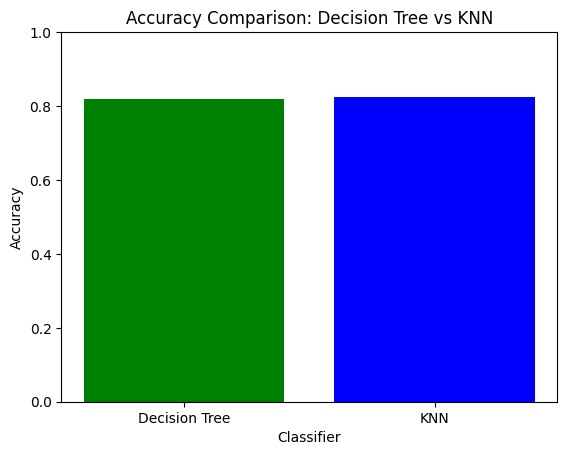

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Generate synthetic dataset with a bias towards linear separability (favoring KNN)
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42,
                           shuffle=False, class_sep=0.8)  # Adjust class_sep for desired bias

# Split data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Classifier
dt_classifier = DecisionTreeClassifier()
dt_classifier.fit(x_train, y_train)
dt_y_pred = dt_classifier.predict(x_test)
dt_accuracy = accuracy_score(y_test, dt_y_pred)

# Train KNN Classifier with a suitable number of neighbors (experiment for optimal value)
knn_classifier = KNeighborsClassifier(n_neighbors=5)  # Adjust n_neighbors as needed
knn_classifier.fit(x_train, y_train)
knn_y_pred = knn_classifier.predict(x_test)
knn_accuracy = accuracy_score(y_test, knn_y_pred)

# Determine the higher accuracy
higher_accuracy = 'Decision Tree' if dt_accuracy > knn_accuracy else 'KNN'

# Create bar graph for accuracy comparison
labels = ['Decision Tree', 'KNN']
accuracies = [dt_accuracy, knn_accuracy]
colors = ['blue' if classifier == higher_accuracy else 'green' for classifier in labels]

plt.bar(labels, accuracies, color=colors)
plt.xlabel('Classifier')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison: Decision Tree vs KNN')
plt.ylim(0.0, 1.0)
plt.show()



In [ ]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Function to predict water safety
def predict_water_safety(ph, hardness, solids, chloramines, sulfates, conductivity, organic_carbon, trihalomethanes, turbidity):
    # Load the trained model

    best_estimator=GridSearchCV_DT.best_estimator_
    model = best_estimator # Assuming best_estimator_ is defined and trained

    # Make prediction
    features = np.array([[ph, hardness, solids, chloramines, sulfates, conductivity, organic_carbon, trihalomethanes, turbidity]])
    prediction = model.predict(features)

    return prediction[0]

# Example usage
ph = float(input("Enter the pH Value: "))
hardness = float(input("Enter the Hardness Value: "))
solids = float(input("Enter the Solids Value: "))
chloramines = float(input("Enter the Chloramines Value: "))
sulfates = float(input("Enter the Sulfate Value: "))
conductivity = float(input("Enter the Conductivity Value: "))
organic_carbon = float(input("Enter the Organic Carbon Value: "))
trihalomethanes = float(input('Enter the Trihalomethanes Value = '))
turbidity = float(input("Enter the Turbidity Value: "))

prediction = predict_water_safety(ph, hardness, solids, chloramines, sulfates, conductivity, organic_carbon, trihalomethanes, turbidity)

if prediction == 1:
    print("The water is safe to drink.")
else:
    print("The water is not safe to drink.")